# Final Project - Data Overview, Data Quality Checks and EDA

This notebook is tailored to the Walmart weekly sales panel dataset.

## Scope
- Problem Definition & Data Overview
- Data quality handling (missingness, duplicates, panel completeness, anomalies)
- EDA (seasonality, holiday effect, ACF/PACF, STL, stationarity)
- Clean export files for downstream feature engineering/modeling


In [24]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid', context='talk')

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'Walmart' / 'Walmart_Sales.csv'
OUT_BASE = PROJECT_ROOT / 'outputs' / 'walmart_section3_4'
FIG_DIR = OUT_BASE / 'figures'
TAB_DIR = OUT_BASE / 'tables'
CLEAN_DIR = OUT_BASE / 'clean_data'

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print('Data path:', DATA_PATH)


Data path: /Users/ruoyaosha/Downloads/TSAF Final Project/Walmart/Walmart_Sales.csv
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## 0) Load and parse

In [25]:
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

if df['Date'].isna().any():
    raise ValueError(f"Unparsable Date rows: {int(df['Date'].isna().sum())}")

df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

summary = {
    'rows': int(len(df)),
    'columns': int(df.shape[1]),
    'n_stores': int(df['Store'].nunique()),
    'n_unique_dates': int(df['Date'].nunique()),
    'start_date': str(df['Date'].min().date()),
    'end_date': str(df['Date'].max().date())
}
print(json.dumps(summary, indent=2))

df.head(3)


{
  "rows": 6435,
  "columns": 8,
  "n_stores": 45,
  "n_unique_dates": 143,
  "start_date": "2010-02-05",
  "end_date": "2012-10-26"
}


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106


**Interpretation**
- This is a weekly panel: multiple stores observed on the same date.
- Forecasting can be done at two levels: store-level panel models or aggregated total-sales series.


## 1) Problem Definition & Data Overview

### Business Objective
- Forecast Walmart weekly sales to support replenishment, labor planning, and promotion readiness.
- Reduce stockout risk (under-forecast) and overstock risk (over-forecast).

### Data Source
- Walmart Sales Forecasting dataset (Kaggle), processed into team modeling files.
  
### Granularity and Evaluation Design
- Time granularity is **weekly**.
- We use a **two-level view**:
- **Aggregate level** for stable signal and fair model comparison.
- **3-store level** for heterogeneity and robustness checks.


## 2) Data quality checks (missing, duplicates, panel completeness)

In [26]:
missing_table = (
    df.isna().sum().to_frame('missing_count')
    .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
    .sort_values('missing_count', ascending=False)
)

dup_full = int(df.duplicated().sum())
dup_store_date = int(df.duplicated(subset=['Store','Date']).sum())

expected_rows = int(df['Store'].nunique() * df['Date'].nunique())
panel_gap_rows = expected_rows - len(df)

print('Duplicate full rows:', dup_full)
print('Duplicate (Store, Date):', dup_store_date)
print('Expected balanced panel rows:', expected_rows)
print('Observed rows:', len(df))
print('Missing panel rows:', panel_gap_rows)

missing_table


Duplicate full rows: 0
Duplicate (Store, Date): 0
Expected balanced panel rows: 6435
Observed rows: 6435
Missing panel rows: 0


,missing_count,missing_pct
Store,0,0.0
Date,0,0.0
Weekly_Sales,0,0.0
Holiday_Flag,0,0.0
Temperature,0,0.0
Fuel_Price,0,0.0
CPI,0,0.0
Unemployment,0,0.0


**Interpretation**
- Missing values and duplicate checks confirm data readiness.
- Balanced-panel check ensures each store has one weekly record per date.


## 3) Build total weekly series (aggregate across stores)

In [27]:
weekly_total = (
    df.groupby('Date', as_index=True)
      .agg(total_weekly_sales=('Weekly_Sales','sum'),
           holiday_share=('Holiday_Flag','mean'),
           avg_temp=('Temperature','mean'),
           avg_fuel_price=('Fuel_Price','mean'),
           avg_cpi=('CPI','mean'),
           avg_unemployment=('Unemployment','mean'))
      .sort_index()
)

weekly_total.head()
print("Dataset shape:", df.shape)

Dataset shape: (6435, 8)


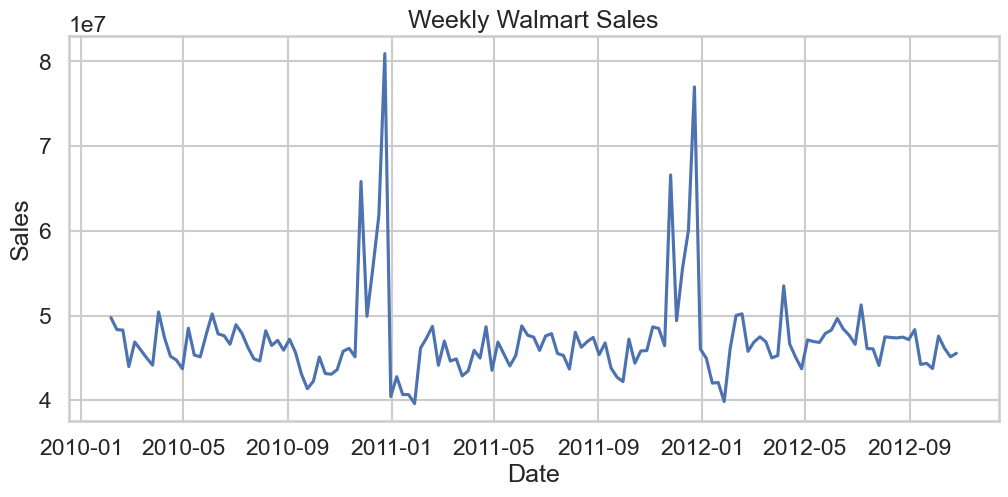

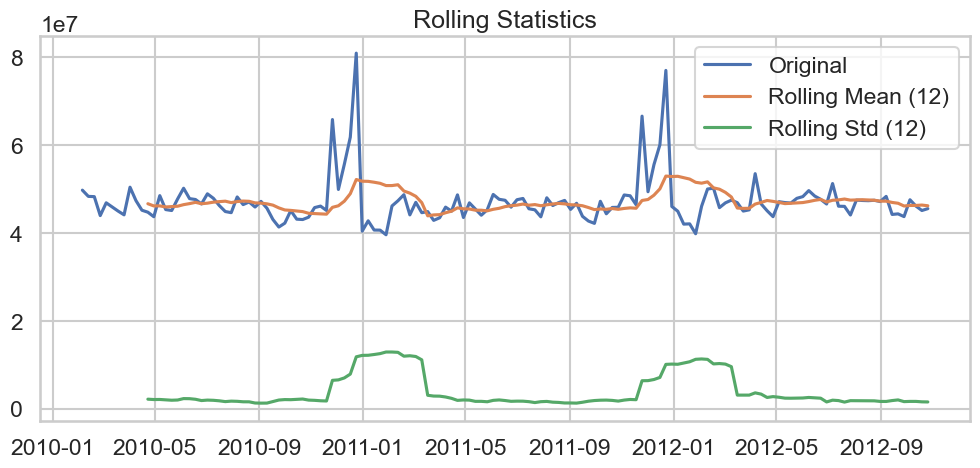

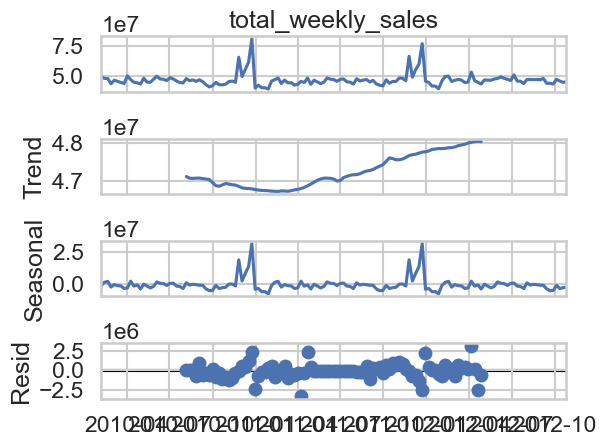

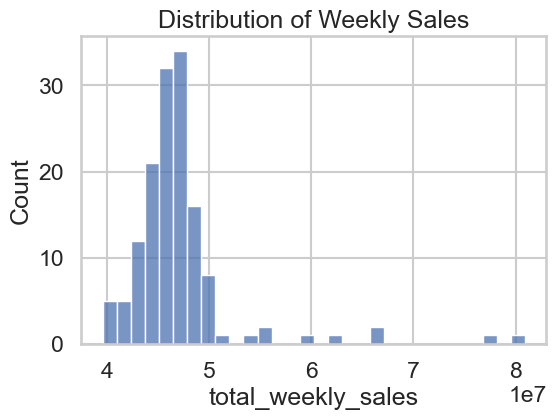

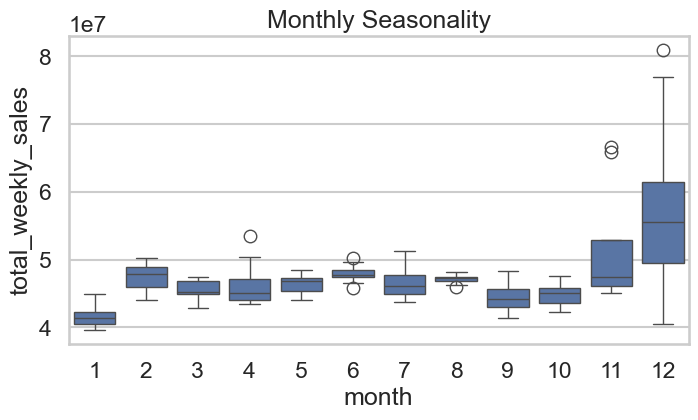

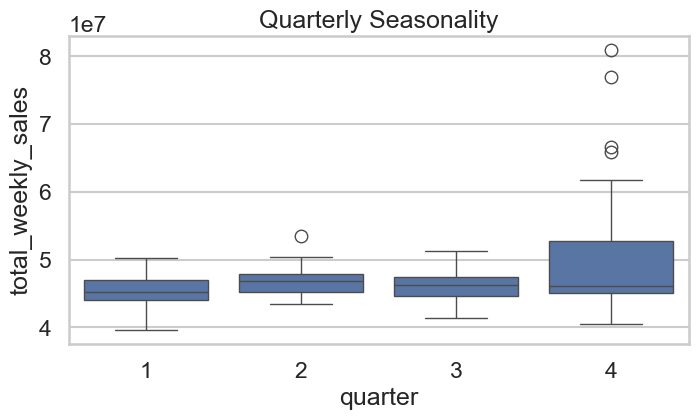

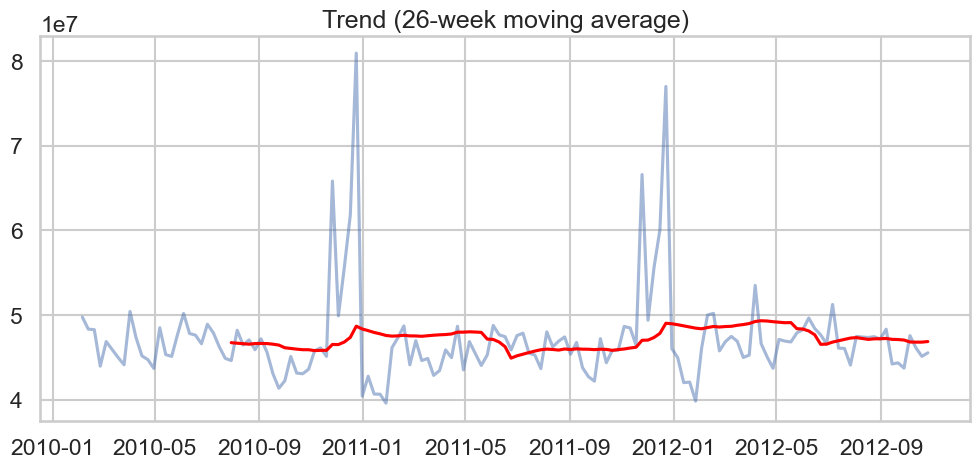

In [28]:
sales = weekly_total["total_weekly_sales"]
plt.figure(figsize=(12,5))
plt.plot(sales)
plt.title("Weekly Walmart Sales")
plt.ylabel("Sales")
plt.xlabel("Date")
plt.show()

rolling_mean = sales.rolling(12).mean()
rolling_std = sales.rolling(12).std()

plt.figure(figsize=(12,5))
plt.plot(sales, label="Original")
plt.plot(rolling_mean, label="Rolling Mean (12)")
plt.plot(rolling_std, label="Rolling Std (12)")
plt.legend()
plt.title("Rolling Statistics")
plt.show()

decomp = seasonal_decompose(sales, model="additive", period=52)
decomp.plot()
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(sales, bins=30)
plt.title("Distribution of Weekly Sales")
plt.show()


weekly_total["month"] = weekly_total.index.month
weekly_total["quarter"] = weekly_total.index.quarter
df["week_of_year"] = weekly_total.index.isocalendar().week.astype(int)

plt.figure(figsize=(8,4))
sns.boxplot(x="month", y="total_weekly_sales", data=weekly_total)
plt.title("Monthly Seasonality")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="quarter", y="total_weekly_sales", data=weekly_total)
plt.title("Quarterly Seasonality")
plt.show()

# Trend Smoothing

plt.figure(figsize=(12,5))
plt.plot(sales, alpha=0.5)
plt.plot(sales.rolling(26).mean(), color="red")
plt.title("Trend (26-week moving average)")
plt.show()

**Interpretation**
- Aggregated weekly total captures enterprise-level demand pattern.
- Exogenous aggregates are retained for later ARIMAX / regression features.


## 4) Seasonality and trend visuals

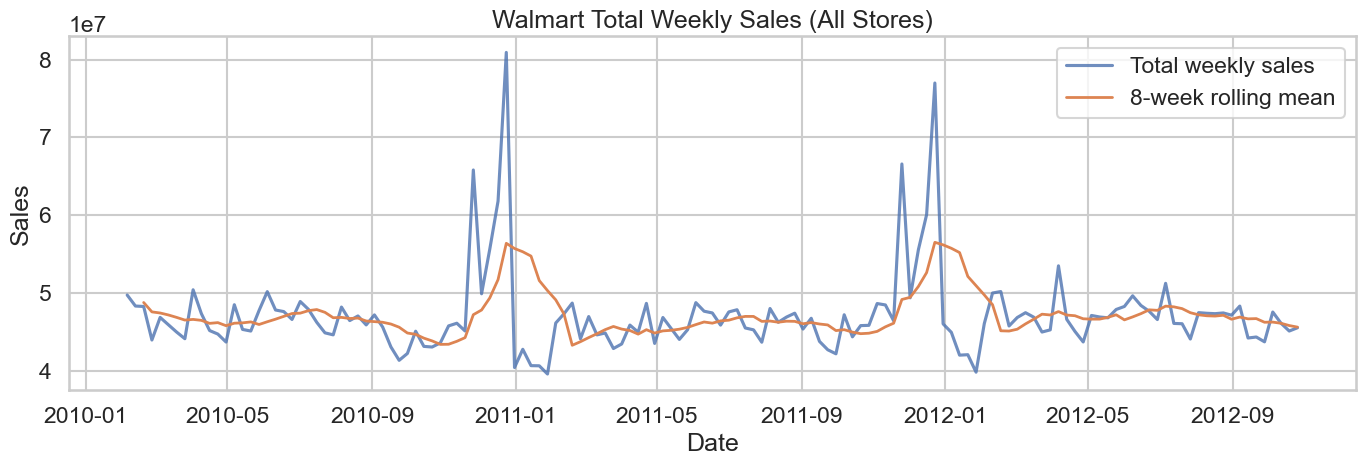

In [29]:
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(weekly_total.index, weekly_total['total_weekly_sales'], alpha=0.8, label='Total weekly sales')
ax.plot(weekly_total.index, weekly_total['total_weekly_sales'].rolling(8, min_periods=3).mean(), linewidth=2, label='8-week rolling mean')
ax.set_title('Walmart Total Weekly Sales (All Stores)')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / 'total_weekly_sales_trend.png', dpi=200)
plt.show()


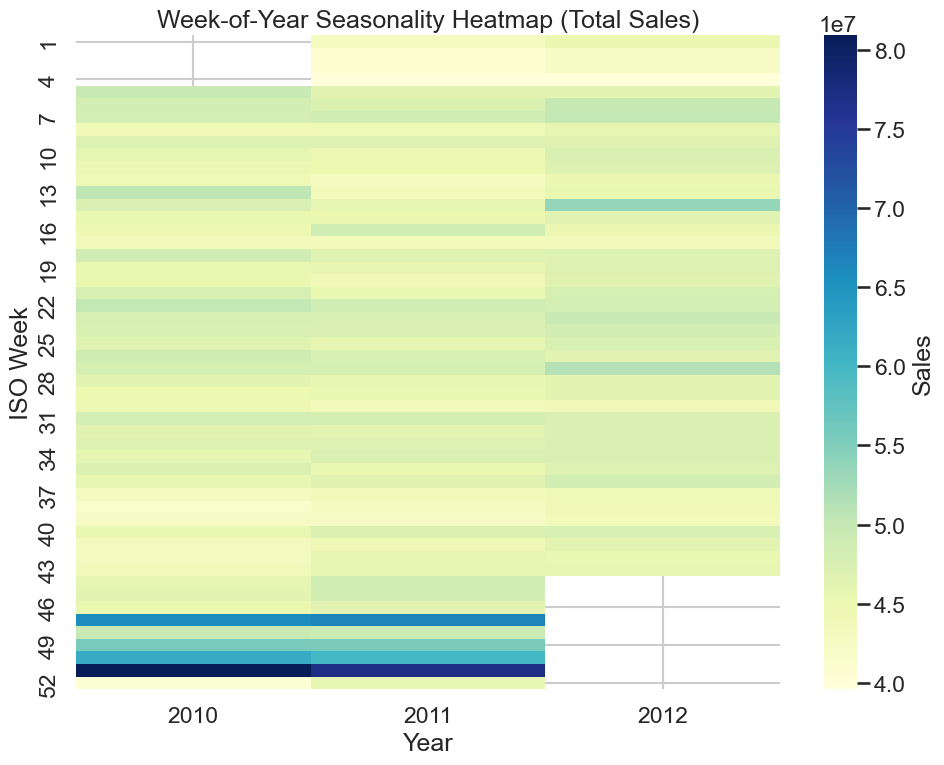

In [30]:
tmp = weekly_total.copy()
tmp['year'] = tmp.index.year
tmp['weekofyear'] = tmp.index.isocalendar().week.astype(int)

pivot = tmp.pivot_table(index='weekofyear', columns='year', values='total_weekly_sales', aggfunc='mean')

plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap='YlGnBu', cbar_kws={'label':'Sales'})
plt.title('Week-of-Year Seasonality Heatmap (Total Sales)')
plt.xlabel('Year')
plt.ylabel('ISO Week')
plt.tight_layout()
plt.savefig(FIG_DIR / 'weekofyear_heatmap.png', dpi=200)
plt.show()


**Interpretation**
- Trend + rolling mean indicate level changes over time.
- Week-of-year heatmap helps identify recurring seasonal peaks (including holiday season effects).


## 5) Holiday effect and store-level holiday lift

In [31]:
holiday_cmp = (
    df.groupby('Holiday_Flag')['Weekly_Sales']
      .agg(['count','mean','median','std'])
      .rename(index={0:'Non-Holiday',1:'Holiday'})
      .round(2)
)
holiday_cmp.to_csv(TAB_DIR / 'holiday_vs_non_holiday_overall.csv')
holiday_cmp


,count,mean,median,std
Holiday_Flag,,,,
Non-Holiday,5985,1041256.38,956211.20,558957.44
Holiday,450,1122887.89,1018538.04,627684.93


In [32]:
store_holiday_lift = (
    df.groupby(['Store','Holiday_Flag'])['Weekly_Sales'].mean().unstack(fill_value=np.nan)
)
store_holiday_lift.columns = ['non_holiday_mean','holiday_mean']
store_holiday_lift['holiday_lift_pct'] = ((store_holiday_lift['holiday_mean'] / store_holiday_lift['non_holiday_mean']) - 1) * 100
store_holiday_lift = store_holiday_lift.sort_values('holiday_lift_pct', ascending=False)
store_holiday_lift.to_csv(TAB_DIR / 'store_holiday_lift.csv')
store_holiday_lift.head(10).round(2)


,non_holiday_mean,holiday_mean,holiday_lift_pct
Store,,,
7,562964.45,672400.26,19.44
35,908099.15,1074348.46,18.31
15,617064.84,706406.02,14.48
5,314892.28,359501.61,14.17
12,999291.92,1138140.42,13.89
29,534375.76,606957.89,13.58
28,1311888.98,1478244.60,12.68
10,1883309.43,2113755.95,12.24
17,887099.02,979796.97,10.45


**Interpretation**
- Holiday effect is heterogeneous across stores.
- This supports segmented modeling or store-specific holiday features in later sections.


## 6) ACF/PACF, stationarity tests, STL

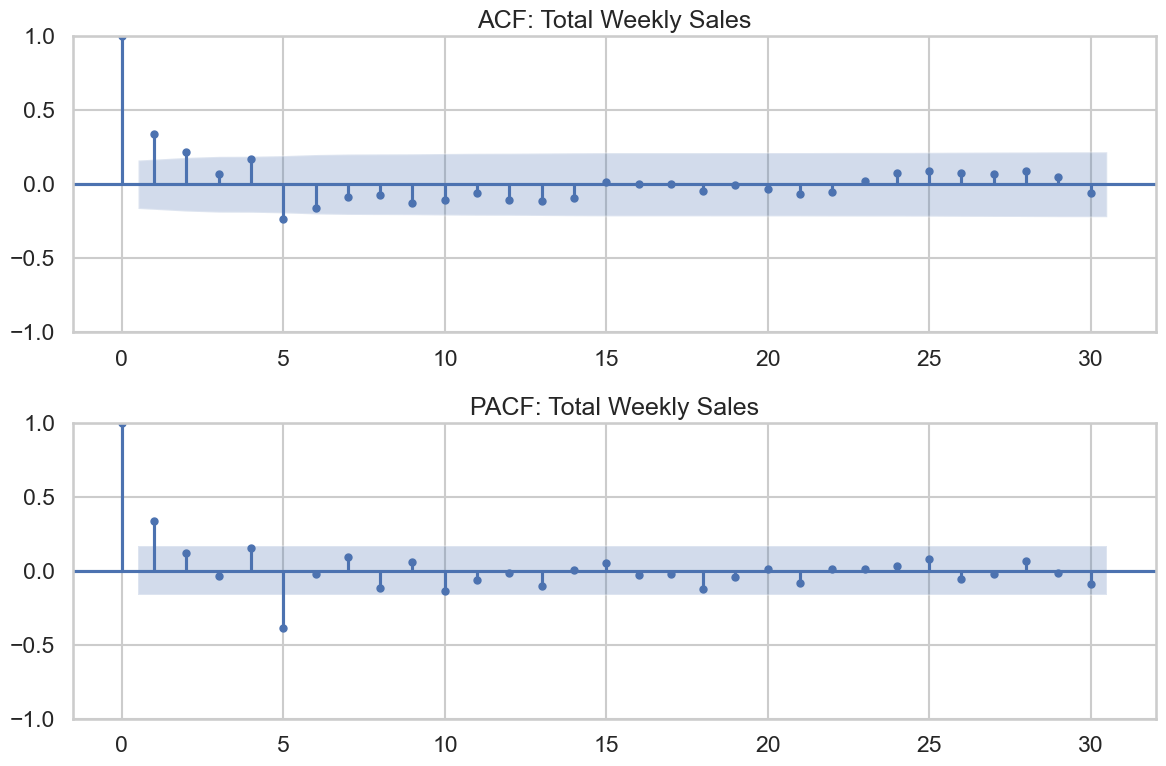

In [33]:
series = weekly_total['total_weekly_sales']

fig, axes = plt.subplots(2,1, figsize=(12,8))
plot_acf(series, lags=30, ax=axes[0], title='ACF: Total Weekly Sales')
plot_pacf(series, lags=30, ax=axes[1], title='PACF: Total Weekly Sales', method='ywm')
plt.tight_layout()
fig.savefig(FIG_DIR / 'acf_pacf_total_weekly.png', dpi=200)
plt.show()


In [34]:
def adf_p(x):
    return adfuller(x.dropna(), autolag='AIC')[1]

def kpss_p(x):
    return kpss(x.dropna(), regression='c', nlags='auto')[1]

diff = series.diff().dropna()

stationarity = pd.DataFrame({
    'raw_adf_p':[adf_p(series)],
    'raw_kpss_p':[kpss_p(series)],
    'diff_adf_p':[adf_p(diff)],
    'diff_kpss_p':[kpss_p(diff)]
}).round(6)

stationarity.to_csv(TAB_DIR / 'stationarity_tests_total_weekly.csv', index=False)
stationarity


/var/folders/52/s8m4p0_x17q16gy06dlm3d280000gn/T/ipykernel_60192/3714303769.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(x.dropna(), regression='c', nlags='auto')[1]
/var/folders/52/s8m4p0_x17q16gy06dlm3d280000gn/T/ipykernel_60192/3714303769.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  return kpss(x.dropna(), regression='c', nlags='auto')[1]


,raw_adf_p,raw_kpss_p,diff_adf_p,diff_kpss_p
0,0.0,0.1,0.0,0.1


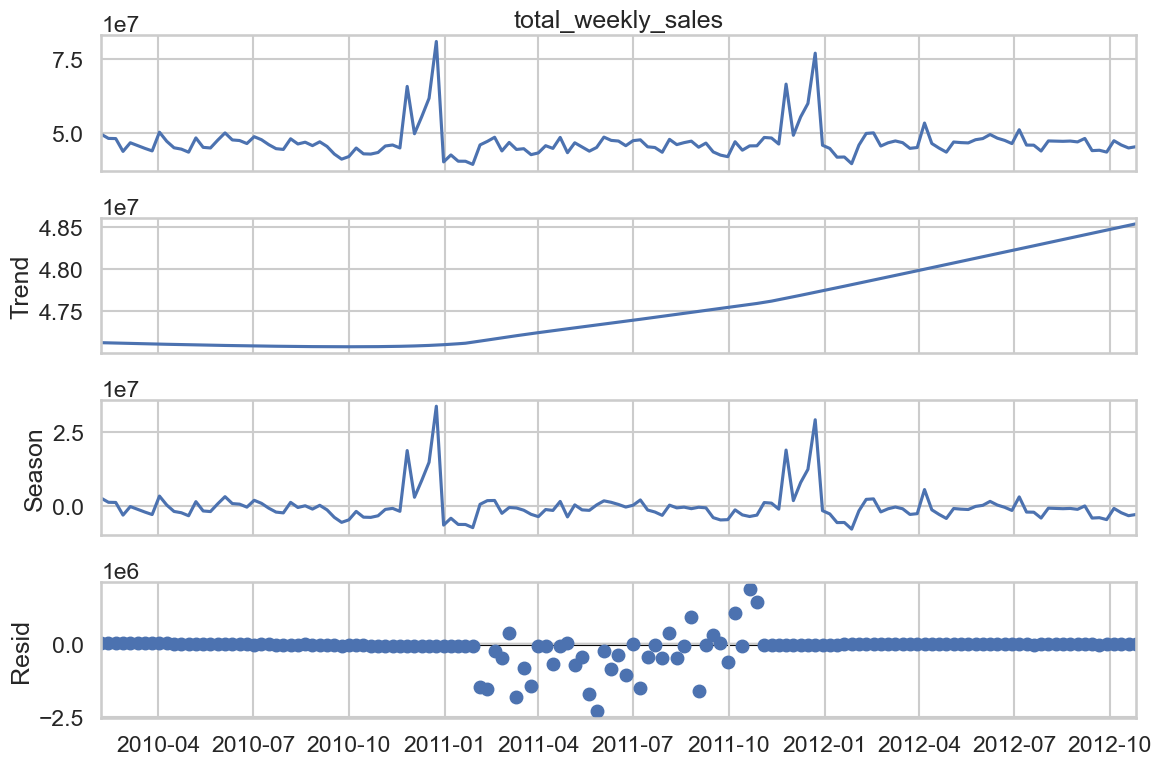

In [35]:
stl = STL(series, period=52, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12,8)
plt.tight_layout()
fig.savefig(FIG_DIR / 'stl_total_weekly_period52.png', dpi=200)
plt.show()


**Interpretation**
- ACF/PACF indicate serial dependence structure for AR/MA terms.
- Use ADF+KPSS jointly: mixed raw evidence is common; differenced series often stabilizes for ARIMA-class models.
- STL decomposition clarifies trend + annual-like weekly seasonality + residual shocks.


## 7) Outlier diagnostics

In [36]:
s = series
q1, q3 = s.quantile(0.25), s.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
iqr_flag = (s < lo) | (s > hi)

med = s.median()
mad = np.median(np.abs(s - med))
if mad == 0:
    mad_flag = pd.Series(False, index=s.index)
else:
    rz = 0.6745 * (s - med) / mad
    mad_flag = np.abs(rz) > 3.5

anom = weekly_total.copy()
anom['iqr_outlier'] = iqr_flag.astype(int)
anom['mad_outlier'] = mad_flag.astype(int)
anom['any_outlier'] = ((anom['iqr_outlier'] + anom['mad_outlier']) > 0).astype(int)

summary_out = {
    'iqr_outliers': int(anom['iqr_outlier'].sum()),
    'mad_outliers': int(anom['mad_outlier'].sum()),
    'union_outliers': int(anom['any_outlier'].sum())
}
print(summary_out)

anom.sort_values('total_weekly_sales', ascending=False).head(12)[['total_weekly_sales','iqr_outlier','mad_outlier']]


{'iqr_outliers': 12, 'mad_outliers': 8, 'union_outliers': 12}


,total_weekly_sales,iqr_outlier,mad_outlier
Date,,,
2010-12-24,80931415.60,1,1
2011-12-23,76998241.31,1,1
2011-11-25,66593605.26,1,1
2010-11-26,65821003.24,1,1
2010-12-17,61820799.85,1,1
2011-12-16,60085695.94,1,1
2010-12-10,55666770.39,1,1
2011-12-09,55561147.70,1,1
2012-04-06,53502315.87,1,0


**Interpretation**
- Outliers likely include true business shocks (promotions/holiday demand), so retain them in baseline and compare robust variants during rolling CV.


## 8) Exogenous variable diagnostics

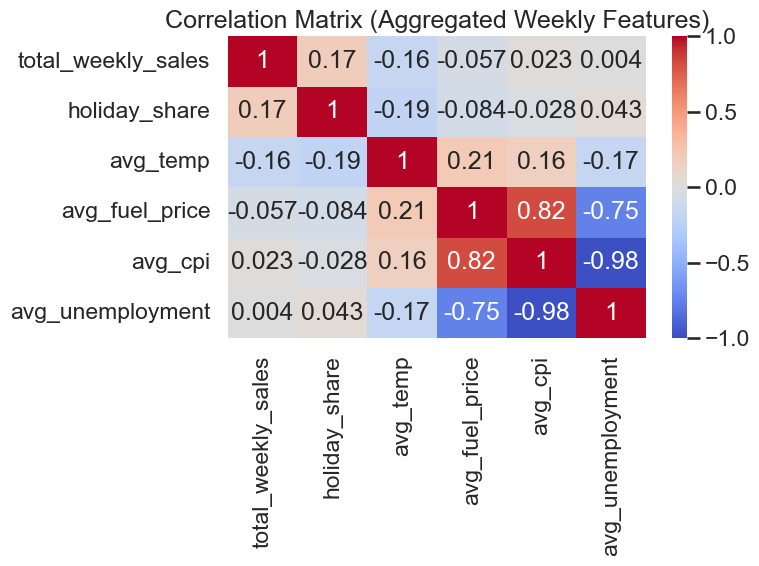

In [37]:
corr = weekly_total[['total_weekly_sales','holiday_share','avg_temp','avg_fuel_price','avg_cpi','avg_unemployment']].corr().round(3)
corr.to_csv(TAB_DIR / 'correlation_matrix_total_weekly.csv')

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix (Aggregated Weekly Features)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png', dpi=200)
plt.show()


**Interpretation**
- Correlation diagnostics help prioritize exogenous candidates (holiday, macro, fuel, weather) for ARIMAX/ML modeling.


## 9) Save quality summary + clean datasets

In [38]:
quality_summary = {
    'raw_rows': int(len(df)),
    'n_stores': int(df['Store'].nunique()),
    'n_unique_dates': int(df['Date'].nunique()),
    'start_date': str(df['Date'].min().date()),
    'end_date': str(df['Date'].max().date()),
    'duplicate_full_rows': int(df.duplicated().sum()),
    'duplicate_store_date_rows': int(df.duplicated(subset=['Store','Date']).sum()),
    'missing_by_column': df.isna().sum().to_dict(),
    'expected_balanced_rows': int(df['Store'].nunique() * df['Date'].nunique()),
    'observed_rows': int(len(df)),
    'missing_panel_rows': int(df['Store'].nunique() * df['Date'].nunique() - len(df)),
    'total_weekly_sales_iqr_outliers': int(anom['iqr_outlier'].sum()),
    'total_weekly_sales_mad_outliers': int(anom['mad_outlier'].sum()),
}

with (TAB_DIR / 'quality_summary.json').open('w') as f:
    json.dump(quality_summary, f, indent=2)

panel_clean = df.copy().sort_values(['Store','Date'])
panel_clean.to_csv(CLEAN_DIR / 'walmart_panel_clean.csv', index=False)

total_weekly_clean = weekly_total.reset_index().rename(columns={'Date':'date'})
total_weekly_clean.to_csv(CLEAN_DIR / 'walmart_total_weekly_clean.csv', index=False)

store_weekly_clean = (
    df[['Store','Date','Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment']]
    .sort_values(['Store','Date'])
    .rename(columns={'Date':'date','Weekly_Sales':'weekly_sales'})
)
store_weekly_clean.to_csv(CLEAN_DIR / 'walmart_store_weekly_clean.csv', index=False)

print('Saved outputs to:', OUT_BASE)
print('panel rows:', len(panel_clean))
print('total weekly rows:', len(total_weekly_clean))
print('store weekly rows:', len(store_weekly_clean))


Saved outputs to: /Users/ruoyaosha/Downloads/TSAF Final Project/outputs/walmart_section3_4
panel rows: 6435
total weekly rows: 143
store weekly rows: 6435
